[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab5-Comp-Mod/MLX-Bio-Qwen/notebooks/01-compmod-intro.ipynb)

# BMED365: Lab 5 - Computational Modeling with Local LLMs
## Introduction to Computational Neuroscience & Medical Physics

**Objective:**
In this notebook, we will use a local Large Language Model (**Qwen 2.5 72B**) running on the M4 Max to simulate complex biological systems. We treat the LLM as a "Senior Computational Colleague"—we ask it to formulate mathematical models (ODEs, SDEs) and write high-performance Python code, which we then validate and run.

**Topics Covered:**
1.  **Dynamical Systems:** The FitzHugh-Nagumo Model and the full Hodgkin-Huxley Model (Action Potentials).
2.  **Stochastic Processes:** Membrane Noise (Ornstein-Uhlenbeck).
3.  **Medical Physics:** MRI Relaxation (Bloch Equations).

**Environment:** `mlx-bio` (Conda)
**Hardware:** Apple M4 Max (Metal Performance Shaders)

---

## Why Computational Modeling in Biomedicine?

Modern biomedicine faces a fundamental challenge: the systems we study — neurons firing, tumors growing, organs responding to therapy — are **far too complex** to understand by intuition alone. A single neuron has thousands of ion channels whose collective behavior produces an action potential; an MRI scanner exploits quantum-mechanical spin dynamics across billions of hydrogen nuclei to produce an image. These phenomena are governed by **mathematical laws**, and computational modeling is the discipline of translating those laws into computer programs that we can simulate, visualize, and interrogate.

### For the medical / biomedical student

You already know the *biology*: you have studied how a nerve impulse propagates, how synaptic noise affects signal reliability, and how MRI contrast arises from tissue-specific relaxation times. What you may not yet have is a language for making those descriptions **quantitative and predictive**. Computational modeling gives you that language. Instead of saying "the membrane potential rises quickly and then recovers slowly," you write down two coupled differential equations (the FitzHugh-Nagumo model) whose solutions *are* the action potential — and you can now ask precise "what if?" questions: What happens if we block the recovery channel? How does the firing threshold change with temperature?

The tools we build in this notebook are not academic exercises — they are the same tools used in **clinical decision support** (e.g., patient-specific cardiac simulations), **drug development** (modeling pharmacokinetics), and **medical imaging** (optimizing MRI pulse sequences for maximum tissue contrast).

### For the computational science / applied mathematics student

You already know the *mathematics*: ordinary differential equations, stochastic calculus, numerical integration. What you may not yet have is a feeling for *why* biologists and clinicians care about certain parameter regimes, or what makes a model biologically plausible versus mathematically convenient. In this lab, every equation comes with a **biological story**: the cubic nonlinearity in the FitzHugh-Nagumo model is not an arbitrary choice — it captures the voltage-gated sodium channel's positive feedback loop. The Ornstein-Uhlenbeck process is not just a toy SDE — it is the simplest model that reproduces the experimentally observed membrane voltage fluctuations due to thousands of random synaptic inputs. The Bloch equations are not abstract vector ODEs — they describe a measurable physical quantity (nuclear magnetization) whose relaxation times directly determine the gray-scale contrast in every clinical MRI scan you have ever seen.

### The role of the LLM

A distinctive feature of this lab is that we use a **local Large Language Model** (Qwen 2.5, 72 billion parameters, running entirely on the Apple M4 Max via MLX) as a "Senior Computational Colleague." We provide it with a carefully crafted system prompt that enforces mathematical rigor and coding standards, then ask it to:

1. **Formulate** the mathematical model (state the governing equations, define parameters and units).
2. **Implement** the model in high-performance Python (vectorized NumPy, SciPy solvers, Euler-Maruyama for SDEs).
3. **Visualize** the results with publication-quality plots.

We then **critically evaluate** the LLM's output — checking the equations against textbook references, verifying numerical stability, and interpreting the results in biological context. This workflow mirrors how computational modeling is increasingly done in research: AI-assisted, but human-validated.

---

## Topic 1 — The Excitable Brain: Action Potentials, the FitzHugh-Nagumo Model, and the Hodgkin-Huxley Model

### The biology: How does a neuron fire?

Every neuron in the brain maintains a **resting membrane potential** of about $-65\;\text{mV}$, created by ion pumps and selective membrane permeability. When a stimulus pushes the voltage above a critical **threshold** (around $-55\;\text{mV}$), an explosive cascade begins:

1. **Depolarization** — Voltage-gated $\text{Na}^+$ channels open, and sodium ions rush into the cell. This is a **positive feedback** loop: the more the voltage rises, the more channels open, which raises the voltage further. The membrane potential shoots up toward $+40\;\text{mV}$ in less than a millisecond.
2. **Repolarization** — After a short delay, $\text{K}^+$ channels open (and $\text{Na}^+$ channels inactivate), driving the voltage back down. This is the **negative feedback** (recovery) that terminates the spike.
3. **Refractory period** — The cell briefly becomes *less* excitable, preventing the signal from traveling backward.

This all-or-nothing event is the **action potential** — the fundamental unit of information in the nervous system.

### The mathematics: From Hodgkin-Huxley to FitzHugh-Nagumo

The full biophysical description of the action potential is the **Hodgkin-Huxley (HH) model** (1952, Nobel Prize 1963), a system of four coupled nonlinear ODEs with voltage-dependent gating variables for each ion channel type ($m$, $h$ for Na$^+$ and $n$ for K$^+$). While extraordinarily successful — it quantitatively reproduces the squid giant axon action potential — the HH model is difficult to analyze geometrically because of its four-dimensional state space. We will implement the full HH model later in this section as a **complementary example**, so you can see each ion channel's contribution to the spike.

In the early 1960s, Richard FitzHugh and Jin-ichi Nagumo independently proposed a **two-variable caricature** that preserves the essential qualitative features of excitability while being simple enough to analyze on the **phase plane** $(V, W)$:

$$
\frac{dV}{dt} = V - \frac{V^3}{3} - W + I_{\text{ext}}
$$

$$
\frac{dW}{dt} = \epsilon\,(V + a - bW)
$$

| Variable / Parameter | Meaning |
|---|---|
| $V(t)$ | **Membrane potential** (fast variable) — captures the explosive depolarization |
| $W(t)$ | **Recovery variable** (slow variable) — lumps together $\text{K}^+$ activation and $\text{Na}^+$ inactivation |
| $I_{\text{ext}}$ | External stimulus current |
| $\epsilon \ll 1$ | **Time-scale separation** — makes $W$ evolve much more slowly than $V$ |
| $a, b$ | Shape parameters controlling the recovery dynamics |

**For the medical student:** The cubic term $V - V^3/3$ is the mathematical encoding of the $\text{Na}^+$ channel's positive feedback — it creates a region of *negative resistance* where a small voltage increase is self-amplifying. The linear recovery variable $W$ plays the role of the $\text{K}^+$ channels that bring the cell back to rest.

**For the applied mathematician:** The FHN system is a prototypical example of a **relaxation oscillator** (when $I_{\text{ext}}$ is large enough) and an **excitable system** (below threshold). Phase-plane analysis reveals the interplay between the cubic $V$-nullcline and the linear $W$-nullcline. The parameter $\epsilon$ creates a **singular perturbation** structure: the trajectory follows the slow manifold (the $V$-nullcline) except during fast jumps — this is exactly the "spike" of the action potential. Bifurcation analysis (varying $I_{\text{ext}}$) shows a **Hopf bifurcation** from a stable fixed point to a limit cycle, corresponding to the transition from quiescence to repetitive firing.

---

## Topic 2 — Noise in the Nervous System: Stochastic Processes and the Ornstein-Uhlenbeck Model

### The biology: Why is the brain noisy?

If you place a microelectrode inside a real neuron and record the membrane potential in the absence of any deliberate stimulus, you will **not** see a flat line at the resting potential. Instead, you observe continuous, irregular fluctuations of $1$–$5\;\text{mV}$ around the mean. This **synaptic noise** arises because:

- A typical cortical neuron receives input from roughly $10\,000$ other neurons.
- Each presynaptic neuron fires stochastically (randomly), releasing neurotransmitter at unpredictable times.
- Each synaptic event produces a small, transient change in the postsynaptic membrane potential.
- The superposition of thousands of these random, overlapping events produces a fluctuating "background hum."

This noise is not a nuisance — it has **functional consequences**:
- **Stochastic resonance:** A weak subthreshold signal that would never trigger a spike on its own can be *detected* when noise randomly pushes the membrane potential above threshold at just the right moment.
- **Spike-time variability:** The timing of action potentials becomes probabilistic, not deterministic. This affects neural coding and information transmission.
- **Spontaneous activity:** Even without external input, neurons fire irregularly — a hallmark of cortical dynamics observed in EEG and fMRI.

### The mathematics: From Brownian motion to the Ornstein-Uhlenbeck process

The simplest model of random fluctuations is **Brownian motion** (the Wiener process $W_t$), but pure Brownian motion has no tendency to return to a mean — it wanders without bound. Real membrane potential fluctuations are different: they are **mean-reverting** (the ion pumps and leak channels always pull the voltage back toward resting potential) and **bounded in variance** (the fluctuations don't grow over time).

The **Ornstein-Uhlenbeck (OU) process** captures both features. It is described by the **stochastic differential equation (SDE)**:

$$
dV = \theta\,(\mu - V)\,dt + \sigma\,dW_t
$$

| Symbol | Meaning |
|---|---|
| $V(t)$ | Membrane potential at time $t$ |
| $\mu$ | **Mean resting potential** (e.g., $-65\;\text{mV}$) — the value $V$ is pulled toward |
| $\theta > 0$ | **Mean-reversion rate** — how quickly $V$ returns to $\mu$ after a perturbation |
| $\sigma$ | **Noise intensity** — amplitude of the random fluctuations |
| $dW_t$ | **Wiener process increment** — a Gaussian random variable with mean $0$ and variance $dt$ |

**For the medical student:** Think of $\theta(\mu - V)$ as a "spring" that always tries to pull $V$ back to the resting potential $\mu$, while $\sigma\,dW_t$ represents the random bombardment from thousands of synapses. The balance between the spring and the noise determines the size of the fluctuations. When $\theta$ is large (strong leak channels), fluctuations are small and fast; when $\sigma$ is large (many active synapses), fluctuations are large.

**For the applied mathematician:** The OU process is the unique **stationary Gaussian Markov process** (by Doob's theorem). Its stationary distribution is $V \sim \mathcal{N}\!\left(\mu,\;\frac{\sigma^2}{2\theta}\right)$, and its autocorrelation decays exponentially with time constant $1/\theta$. Unlike a standard ODE, this SDE cannot be solved with `scipy.integrate.odeint` because the Wiener process is **nowhere differentiable** — the derivative $dW_t/dt$ does not exist in the classical sense. Instead, we use the **Euler-Maruyama method**, the stochastic analogue of the Euler method:

$$
V_{n+1} = V_n + \theta\,(\mu - V_n)\,\Delta t + \sigma\,\sqrt{\Delta t}\;\xi_n, \qquad \xi_n \sim \mathcal{N}(0,1)
$$

This is a first-order **strong convergence** scheme (order $0.5$ in the standard SDE sense). Higher-order methods (Milstein, stochastic Runge-Kutta) exist but are unnecessary here because the OU process has **additive noise** (the diffusion coefficient $\sigma$ does not depend on $V$), so Euler-Maruyama already achieves strong order $1.0$.

---

## Topic 3 — Medical Physics: MRI Relaxation and the Bloch Equations

### The biology and physics: How does MRI produce an image?

Magnetic Resonance Imaging (MRI) is one of the most powerful diagnostic tools in medicine — it provides exquisite soft-tissue contrast without ionizing radiation. The basic principle relies on the quantum-mechanical property of **nuclear spin**, possessed by hydrogen nuclei ($^1\text{H}$ protons) that are abundant in water and fat throughout the body.

**The key steps:**

1. **Alignment.** When a patient is placed in the strong static magnetic field $B_0$ (typically $1.5$ or $3.0\;\text{T}$), the proton spins partially align with the field, creating a net **magnetization vector** $\vec{M} = (M_x, M_y, M_z)$. At thermal equilibrium, $\vec{M}$ points along $B_0$ (the $z$-axis): $\vec{M} = (0, 0, M_0)$.

2. **Excitation.** A brief radiofrequency (RF) pulse at the **Larmor frequency** ($\omega_0 = \gamma B_0 \approx 128\;\text{MHz}$ at $3\;\text{T}$, where $\gamma$ is the gyromagnetic ratio) tips $\vec{M}$ away from the $z$-axis into the transverse ($xy$) plane. A $90°$ pulse rotates $\vec{M}$ fully into the transverse plane.

3. **Relaxation.** After the RF pulse, $\vec{M}$ **precesses** around $B_0$ and simultaneously **relaxes** back to equilibrium through two independent processes:
   - **T1 relaxation (longitudinal / spin-lattice):** The $M_z$ component recovers exponentially toward $M_0$ as protons transfer energy to the surrounding molecular lattice. The time constant $T_1$ depends on tissue type (e.g., $T_1 \approx 800\;\text{ms}$ for white matter, $\approx 1300\;\text{ms}$ for gray matter, $\approx 4000\;\text{ms}$ for cerebrospinal fluid at $3\;\text{T}$).
   - **T2 relaxation (transverse / spin-spin):** The $M_{xy}$ component decays exponentially toward zero as protons lose phase coherence due to local magnetic field inhomogeneities. $T_2$ is always shorter than $T_1$.

4. **Signal and contrast.** The precessing transverse magnetization induces a voltage in a receiver coil — this is the MRI signal. Because different tissues have different $T_1$ and $T_2$ values, choosing the right **repetition time (TR)** and **echo time (TE)** in the pulse sequence creates contrast: on a "T1-weighted" image, tissues with short $T_1$ (like white matter) appear bright, while those with long $T_1$ (like CSF) appear dark.

### The mathematics: The Bloch equations

Felix Bloch (Nobel Prize 1952) described the time evolution of the magnetization vector in a phenomenological set of coupled ODEs known as the **Bloch equations**:

$$
\frac{dM_x}{dt} = \gamma\,(\vec{M} \times \vec{B})_x - \frac{M_x}{T_2}
$$

$$
\frac{dM_y}{dt} = \gamma\,(\vec{M} \times \vec{B})_y - \frac{M_y}{T_2}
$$

$$
\frac{dM_z}{dt} = \gamma\,(\vec{M} \times \vec{B})_z - \frac{M_z - M_0}{T_1}
$$

where $\vec{B}$ is the total magnetic field (static $B_0$ plus any RF or gradient fields), and the cross product $\vec{M} \times \vec{B}$ describes the **precession**.

| Parameter | Meaning | Typical values ($3\;\text{T}$) |
|---|---|---|
| $M_0$ | Equilibrium magnetization (proportional to proton density) | Normalized to $1.0$ |
| $T_1$ | Longitudinal relaxation time | WM $\approx 800\;\text{ms}$, GM $\approx 1300\;\text{ms}$, CSF $\approx 4000\;\text{ms}$ |
| $T_2$ | Transverse relaxation time | WM $\approx 80\;\text{ms}$, GM $\approx 100\;\text{ms}$, CSF $\approx 2000\;\text{ms}$ |
| $\gamma / 2\pi$ | Gyromagnetic ratio for $^1\text{H}$ | $42.58\;\text{MHz/T}$ |

**For the medical student:** The exponential recovery $M_z(t) = M_0\,(1 - e^{-t/T_1})$ is the key equation for understanding T1-weighted contrast. If you acquire the signal at a time $t = \text{TR}$ after the excitation pulse, the signal from each tissue is proportional to $M_z(\text{TR})$. At short TR ($\sim 500\;\text{ms}$), white matter ($T_1 = 800\;\text{ms}$) has already recovered significantly, while CSF ($T_1 = 4000\;\text{ms}$) has barely recovered — producing strong contrast. At very long TR, all tissues have fully recovered and the contrast disappears. The "contrast window" where $T_1$-weighting is maximized corresponds to $\text{TR}$ values between the shortest and longest $T_1$ in the tissue of interest.

**For the applied mathematician:** The Bloch equations are a **linear time-invariant system** (in the rotating frame, when relaxation dominates over off-resonance effects). The general solution is a superposition of exponential decays — $T_1$ governs the eigenvalue along $z$, and $T_2$ governs the eigenvalues in the transverse plane. In the rotating frame at the Larmor frequency, the cross-product terms simplify dramatically, and the system decouples into independent equations for $M_z$ and $M_{xy} = M_x + iM_y$. For computational MRI simulation (e.g., generating synthetic images of the brain), the Bloch equations must be solved for every voxel in the image, making **vectorized implementations** essential — we represent all voxels as arrays and solve them simultaneously using NumPy broadcasting, avoiding Python-level loops entirely.

---

## How the Three Topics Connect — A Roadmap

The three examples in this notebook are not chosen at random. They form a **progression** through three fundamental classes of mathematical models used across biomedicine and computational science:

| Example | Model type | Mathematical machinery | Biological question |
|---|---|---|---|
| **1a. FitzHugh-Nagumo** | Deterministic ODE system (2D) | Phase-plane analysis, nullclines, bifurcations | How does a neuron generate an all-or-nothing action potential? (qualitative) |
| **1b. Hodgkin-Huxley** | Deterministic ODE system (4D) | Numerical integration, ionic current decomposition | How do specific ion channels (Na$^+$, K$^+$) orchestrate the action potential? (biophysical) |
| **2. Ornstein-Uhlenbeck** | Stochastic differential equation (SDE) | Euler-Maruyama integration, Wiener process | How does synaptic noise shape membrane potential fluctuations? |
| **3. Bloch equations** | Linear ODE system (with physical parameters) | Exponential solutions, vectorized computation | How do tissue-specific relaxation times create MRI contrast? |

**The common thread** is that in each case we:
1. Start from a **biological or physical phenomenon** that is well understood qualitatively.
2. Write down a **mathematical model** (a system of differential equations) that captures the essential dynamics.
3. **Implement** and **simulate** the model computationally to obtain quantitative predictions.
4. **Visualize** and **interpret** the results in both mathematical and biomedical terms.

In this lab, steps 1-3 are performed in dialogue with the LLM, and step 4 is where *you* bring your domain expertise — whether that is clinical knowledge of MRI contrast or mathematical insight into bifurcation theory.

**Let's begin.**

In [1]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- Detect runtime environment ---
IN_COLAB = 'google.colab' in sys.modules

HAS_MLX = False
try:
    import mlx.core as mx
    from mlx_lm import load, generate
    from mlx_lm.sample_utils import make_sampler
    HAS_MLX = True
except ImportError:
    pass

# Configure Plotting Style for the Course
try:
    plt.style.use('seaborn-v0_8-paper')
except OSError:
    plt.style.use('seaborn-paper')  # Fallback for older matplotlib versions
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 140

if HAS_MLX:
    print(f"✅ MLX Device: {mx.default_device()}")
    print("   LLM inference will be available in this session.")
elif IN_COLAB:
    print("☁️  Running on Google Colab.")
    print("   LLM cells will be skipped (MLX requires Apple Silicon).")
    print("   Pre-generated LLM responses are shown in the markdown cells.")
    print("   All standard Python code (NumPy, SciPy, Matplotlib) will run normally.")
else:
    print("ℹ️  MLX not available (no Apple Silicon detected).")
    print("   LLM cells will be skipped; pre-generated responses are shown in markdown cells.")
    print("   All standard Python code (NumPy, SciPy, Matplotlib) will run normally.")

✅ MLX Device: Device(gpu, 0)
   LLM inference will be available in this session.


In [2]:
%%time
if HAS_MLX:
    # 1. Load the Model (Cached in ~/.cache/huggingface/hub)
    model_id = "mlx-community/Qwen2.5-72B-Instruct-4bit"
    print(f"Loading {model_id} into Unified Memory...")

    # We use the default tokenizer config
    model, tokenizer = load(model_id)

    # 2. Define the "Professor" Persona (System Prompt)
    SYSTEM_PROMPT = """
    You are an expert Professor of Computational Medicine and Biomedical Physics.
    Your goal is to translate biological problems into precise, high-performance computational models.

    **Methodology:**
    1.  **Dynamical Systems:** Use Phase Plane analysis (Nullclines) for excitability.
    2.  **Stochasticity:** Use Euler-Maruyama for SDEs (never standard ODE solvers).
    3.  **MRI/Physics:** Use Vectorized Bloch Equations.

    **Coding Standards:**
    * Use `numpy` vectorization (avoid loops).
    * Always define units and governing equations in LaTeX.
    * Use `scipy.integrate` for deterministic systems.
    """

    def ask_professor(query, max_tokens=2048):
        """
        Sends a query to the local LLM with the Professor persona.
        """
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": query}
        ]
        
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        
        print(f"🧠 Professor is thinking about: '{query}'...")
        start = time.time()
        
        response = generate(
            model, 
            tokenizer, 
            prompt=prompt, 
            verbose=False, 
            max_tokens=max_tokens, 
            sampler=make_sampler(temp=0.3) # Low temp for mathematical precision
        )
        
        end = time.time()
        print(f"✅ Generated in {end - start:.2f}s")
        return response

    print("✅ Model & Agent Ready.")
else:
    print("⏭️  Skipping model loading (MLX not available).")
    print("   The LLM responses are preserved in the markdown cells below.")

Loading mlx-community/Qwen2.5-72B-Instruct-4bit into Unified Memory...


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

✅ Model & Agent Ready.
CPU times: user 421 ms, sys: 5.66 s, total: 6.08 s
Wall time: 2.68 s


## Example 1: The Excitable Brain (Deterministic ODEs)

We start with a classic model of neuronal excitability: the **FitzHugh-Nagumo (FHN)** model. It is a 2D simplification of the Hodgkin-Huxley model, perfect for understanding "Phase Space" dynamics.

**The Prompt:**
We will ask the model to:
1.  Define and describe the equations conceptuall and mathematically
2.  Make a schematic illustration


In [3]:
%%time
# We ask the LLM to describe the FHN model for us
query_fhn_description = """
I need to describe the FitzHugh-Nagumo (FNN) model.
1. Describe FNN conseptually
2. Describe the equations mathematically (using latex);  do not use \[ and \] but $$, not \( X \) but $X$ where X is a symbol or string
3. Make a schematic illustration in python
"""

if HAS_MLX:
    response_fhn_description = ask_professor(query_fhn_description)
    print(response_fhn_description)
else:
    print("⏭️  LLM not available — see pre-generated response in the markdown cell below.")


🧠 Professor is thinking about: '
I need to describe the FitzHugh-Nagumo (FNN) model.
1. Describe FNN conseptually
2. Describe the equations mathematically (using latex);  do not use \[ and \] but $$, not \( X \) but $X$ where X is a symbol or string
3. Make a schematic illustration in python
'...
✅ Generated in 94.28s
### 1. Conceptual Description of the FitzHugh-Nagumo (FHN) Model

The FitzHugh-Nagumo (FHN) model is a simplified version of the Hodgkin-Huxley model, which describes the behavior of action potentials in neurons. The FHN model captures the essential dynamics of excitable systems, such as neurons, with a minimal set of equations. It is particularly useful for studying the qualitative behavior of such systems, including the generation and propagation of action potentials.

The model consists of two variables:
- $v$: the membrane potential, which represents the fast dynamics of the system.
- $w$: the recovery variable, which represents the slower dynamics and helps to reset 

🧠 Professor is thinking about: '
I need to describe the FitzHugh-Nagumo (FNN) model.
1. Describe FNN conseptually
2. Describe the equations mathematically (using latex);  do not use \[ and \] but $$, not \( X \) but $X$ where X is a symbol or string
3. Make a schematic illustration in python
'...
✅ Generated in 84.70s
### 1. Conceptual Description of the FitzHugh-Nagumo (FHN) Model

The FitzHugh-Nagumo (FHN) model is a simplified version of the Hodgkin-Huxley model, which describes the behavior of action potentials in neurons. The FHN model captures the essential dynamics of excitable systems with two variables: a fast variable representing the membrane potential ($V$) and a slow variable representing a recovery variable ($W$). The model is particularly useful for studying phenomena such as oscillations, excitability, and wave propagation in biological systems.

### 2. Mathematical Description of the FHN Model

The FHN model is described by the following system of differential equations:

$$
\frac{dV}{dt} = V - \frac{V^3}{3} - W + I
$$

$$
\frac{dW}{dt} = \epsilon (V + a - bW)
$$

where:
- $V$ is the membrane potential.
- $W$ is the recovery variable.
- $I$ is the external stimulus current.
- $\epsilon$ is a small positive parameter that determines the time scale separation between the fast variable $V$ and the slow variable $W$.
- $a$ and $b$ are parameters that control the dynamics of the recovery variable.

### 3. Schematic Illustration in Python

To create a schematic illustration of the FHN model, we can plot the nullclines and a phase portrait. The nullclines are the curves where the derivatives of $V$ and $W$ are zero, which help in understanding the equilibrium points and the flow of the system.

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
epsilon = 0.08
a = 0.7
b = 0.8
I = 0.5

# Define the FHN model
def fhn_model(t, y):
    V, W = y
    dVdt = V - V**3 / 3 - W + I
    dWdt = epsilon * (V + a - b * W)
    return [dVdt, dWdt]

# Time span for the simulation
t_span = (0, 50)
y0 = [0, 0]  # Initial conditions

# Solve the ODE
sol = solve_ivp(fhn_model, t_span, y0, dense_output=True)

# Plot the phase portrait
V = np.linspace(-2, 2, 400)
W = np.linspace(-1, 1, 400)
V_grid, W_grid = np.meshgrid(V, W)

dVdt = V_grid - V_grid**3 / 3 - W_grid + I
dWdt = epsilon * (V_grid + a - b * W_grid)

plt.figure(figsize=(10, 6))
plt.streamplot(V, W, dVdt, dWdt, color='gray', density=1.5, linewidth=1, arrowsize=1.5)
plt.plot(sol.y[0], sol.y[1], 'b', label='Trajectory')
plt.xlabel('$V$ (Membrane Potential)')
plt.ylabel('$W$ (Recovery Variable)')
plt.title('FitzHugh-Nagumo Model Phase Portrait')
plt.legend()
plt.grid(True)
plt.show()
```

### Explanation of the Code

1. **Parameters**: The parameters $\epsilon$, $a$, $b$, and $I$ are defined.
2. **Model Definition**: The `fhn_model` function defines the system of differential equations.
3. **Time Span and Initial Conditions**: The time span for the simulation and initial conditions are set.
4. **Solving the ODE**: The `solve_ivp` function from `scipy.integrate` is used to solve the system of ODEs.
5. **Phase Portrait**: The phase portrait is plotted using `streamplot` to show the direction field, and the trajectory of the system is plotted using the solution from `solve_ivp`.

This code will generate a phase portrait that illustrates the dynamics of the FitzHugh-Nagumo model, showing the nullclines and the trajectory of the system over time.
CPU times: user 12.3 s, sys: 7.14 s, total: 19.5 s
Wall time: 1min 24s

#### Running the generated Python code:

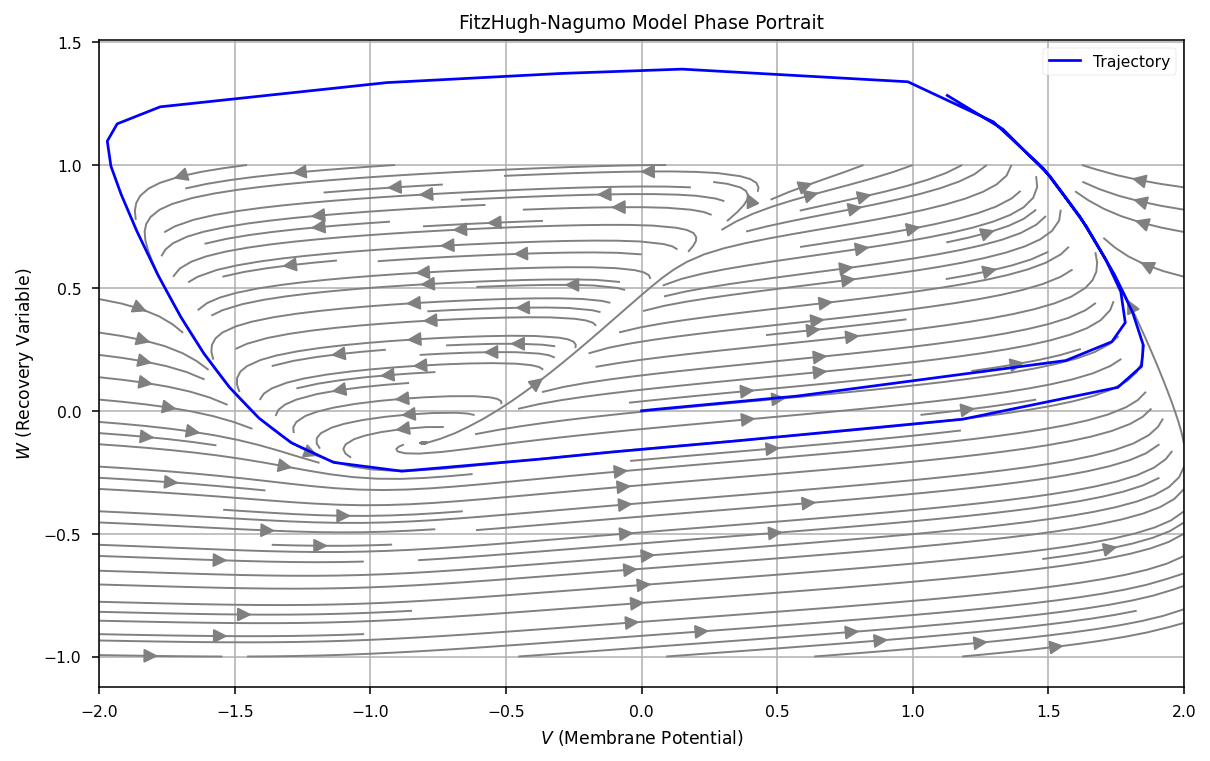

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
epsilon = 0.08
a = 0.7
b = 0.8
I = 0.5

# Define the FHN model
def fhn_model(t, y):
    V, W = y
    dVdt = V - V**3 / 3 - W + I
    dWdt = epsilon * (V + a - b * W)
    return [dVdt, dWdt]

# Time span for the simulation
t_span = (0, 50)
y0 = [0, 0]  # Initial conditions

# Solve the ODE
sol = solve_ivp(fhn_model, t_span, y0, dense_output=True)

# Plot the phase portrait
V = np.linspace(-2, 2, 400)
W = np.linspace(-1, 1, 400)
V_grid, W_grid = np.meshgrid(V, W)

dVdt = V_grid - V_grid**3 / 3 - W_grid + I
dWdt = epsilon * (V_grid + a - b * W_grid)

plt.figure(figsize=(10, 6))
plt.streamplot(V, W, dVdt, dWdt, color='gray', density=1.5, linewidth=1, arrowsize=1.5)
plt.plot(sol.y[0], sol.y[1], 'b', label='Trajectory')
plt.xlabel('$V$ (Membrane Potential)')
plt.ylabel('$W$ (Recovery Variable)')
plt.title('FitzHugh-Nagumo Model Phase Portrait')
plt.legend()
plt.grid(True)
plt.show()

#### Explanation of the Code

1. **Parameters**: The parameters $\epsilon$, $a$, $b$, and $I$ are defined.
2. **Model Definition**: The `fhn_model` function defines the system of differential equations.
3. **Time Span and Initial Conditions**: The time span for the simulation and initial conditions are set.
4. **Solving the ODE**: The `solve_ivp` function from `scipy.integrate` is used to solve the system of ODEs.
5. **Phase Portrait**: The phase portrait is plotted using `streamplot` to show the direction field, and the trajectory of the system is plotted using the solution from `solve_ivp`.

**The New Prompt:**
We will then ask the model to:
1.  Define the equations.
2.  Simulate a neuron firing.
3.  **Crucially:** Plot the "Nullclines" (where $dV/dt = 0$) to show the stability.

In [5]:
%%time
# We ask the LLM to generate the code for us
query_fhn = """
I need to model a neuron using the FitzHugh-Nagumo equations.
1. Define the ODEs with parameters a=0.7, b=0.8, tau=12.5.
2. Solve it for 100ms with an injected current I_ext = 0.5.
3. Plot two subplots: 
   (a) Voltage vs Time 
   (b) The Phase Plane (V vs W) with Nullclines and the trajectory.
"""

if HAS_MLX:
    response_fhn = ask_professor(query_fhn)
    print(response_fhn)
else:
    print("⏭️  LLM not available — see pre-generated response in the markdown cell below.")

🧠 Professor is thinking about: '
I need to model a neuron using the FitzHugh-Nagumo equations.
1. Define the ODEs with parameters a=0.7, b=0.8, tau=12.5.
2. Solve it for 100ms with an injected current I_ext = 0.5.
3. Plot two subplots: 
   (a) Voltage vs Time 
   (b) The Phase Plane (V vs W) with Nullclines and the trajectory.
'...
✅ Generated in 101.80s
Certainly! Let's go through the steps to model the FitzHugh-Nagumo (FHN) equations and plot the required subplots.

### FitzHugh-Nagumo Equations

The FitzHugh-Nagumo equations are a simplified model of the Hodgkin-Huxley equations and are given by:

\[
\begin{cases}
\frac{dV}{dt} = V - \frac{V^3}{3} - W + I_{\text{ext}} \\
\frac{dW}{dt} = \frac{1}{\tau} (V + a - bW)
\end{cases}
\]

where:
- \( V \) is the membrane potential.
- \( W \) is the recovery variable.
- \( I_{\text{ext}} \) is the external current.
- \( a \), \( b \), and \( \tau \) are parameters.

Given parameters:
- \( a = 0.7 \)
- \( b = 0.8 \)
- \( \tau = 12.5 \)
- \( I_

🧠 Professor is thinking about: '
I need to model a neuron using the FitzHugh-Nagumo equations.
1. Define the ODEs with parameters a=0.7, b=0.8, tau=12.5.
2. Solve it for 100ms with an injected current I_ext = 0.5.
3. Plot two subplots: 
   (a) Voltage vs Time 
   (b) The Phase Plane (V vs W) with Nullclines and the trajectory.
'...
✅ Generated in 103.34s
Certainly! The FitzHugh-Nagumo (FHN) model is a simplified version of the Hodgkin-Huxley model and is often used to study the dynamics of neurons. The FHN model is described by the following system of ODEs:

\[
\begin{cases}
\frac{dV}{dt} = V - \frac{V^3}{3} - W + I_{\text{ext}} \\
\frac{dW}{dt} = \frac{V + a - bW}{\tau}
\end{cases}
\]

where:
- \( V \) is the membrane potential.
- \( W \) is a recovery variable.
- \( I_{\text{ext}} \) is the external applied current.
- \( a \), \( b \), and \( \tau \) are parameters.

Given the parameters \( a = 0.7 \), \( b = 0.8 \), and \( \tau = 12.5 \), and an external current \( I_{\text{ext}} = 0.5 \), we can solve the system for 100 ms.

Here is the Python code to define the ODEs, solve them, and plot the results:

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the parameters
a = 0.7
b = 0.8
tau = 12.5
I_ext = 0.5

# Define the FitzHugh-Nagumo ODEs
def fhn_ode(t, y):
    V, W = y
    dVdt = V - V**3 / 3 - W + I_ext
    dWdt = (V + a - b * W) / tau
    return [dVdt, dWdt]

# Initial conditions
V0 = -1.0
W0 = 1.0
y0 = [V0, W0]

# Time span
t_span = (0, 100)
t_eval = np.linspace(0, 100, 1000)

# Solve the ODEs
sol = solve_ivp(fhn_ode, t_span, y0, t_eval=t_eval)

# Extract the solution
V = sol.y[0]
W = sol.y[1]
t = sol.t

# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot Voltage vs Time
ax1.plot(t, V, label='V(t)')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('Voltage vs Time')
ax1.legend()

# Plot the Phase Plane (V vs W)
ax2.plot(V, W, label='Trajectory')
ax2.set_xlabel('Voltage (V)')
ax2.set_ylabel('Recovery Variable (W)')
ax2.set_title('Phase Plane (V vs W)')

# Plot Nullclines
V_nullcline = np.linspace(-2, 2, 400)
W_nullcline = V_nullcline - V_nullcline**3 / 3 + I_ext
ax2.plot(V_nullcline, W_nullcline, 'r--', label='V-nullcline')

W_nullcline = (V_nullcline + a) / b
ax2.plot(V_nullcline, W_nullcline, 'b--', label='W-nullcline')

ax2.legend()

plt.tight_layout()
plt.show()
```

### Explanation:
1. **ODE Definition:**
   - The function `fhn_ode` defines the FitzHugh-Nagumo ODEs.
   - The parameters \( a \), \( b \), and \( \tau \) are set to the given values.
   - The external current \( I_{\text{ext}} \) is set to 0.5.

2. **Initial Conditions:**
   - The initial conditions for \( V \) and \( W \) are set to \(-1.0\) and \(1.0\), respectively.

3. **Time Span and Evaluation:**
   - The time span is set from 0 to 100 ms.
   - The `t_eval` array is used to specify the time points at which the solution is evaluated.

4. **Solving the ODEs:**
   - The `solve_ivp` function from `scipy.integrate` is used to solve the ODEs.

5. **Plotting:**
   - The first subplot shows the voltage \( V \) as a function of time.
   - The second subplot shows the phase plane with the trajectory of \( V \) vs \( W \).
   - The nullclines are plotted as dashed lines:
     - The \( V \)-nullcline is where \( \frac{dV}{dt} = 0 \).
     - The \( W \)-nullcline is where \( \frac{dW}{dt} = 0 \).

This code will generate the desired plots for the FitzHugh-Nagumo model with the specified parameters and external current.
CPU times: user 14.9 s, sys: 8.64 s, total: 23.6 s
Wall time: 1min 43s

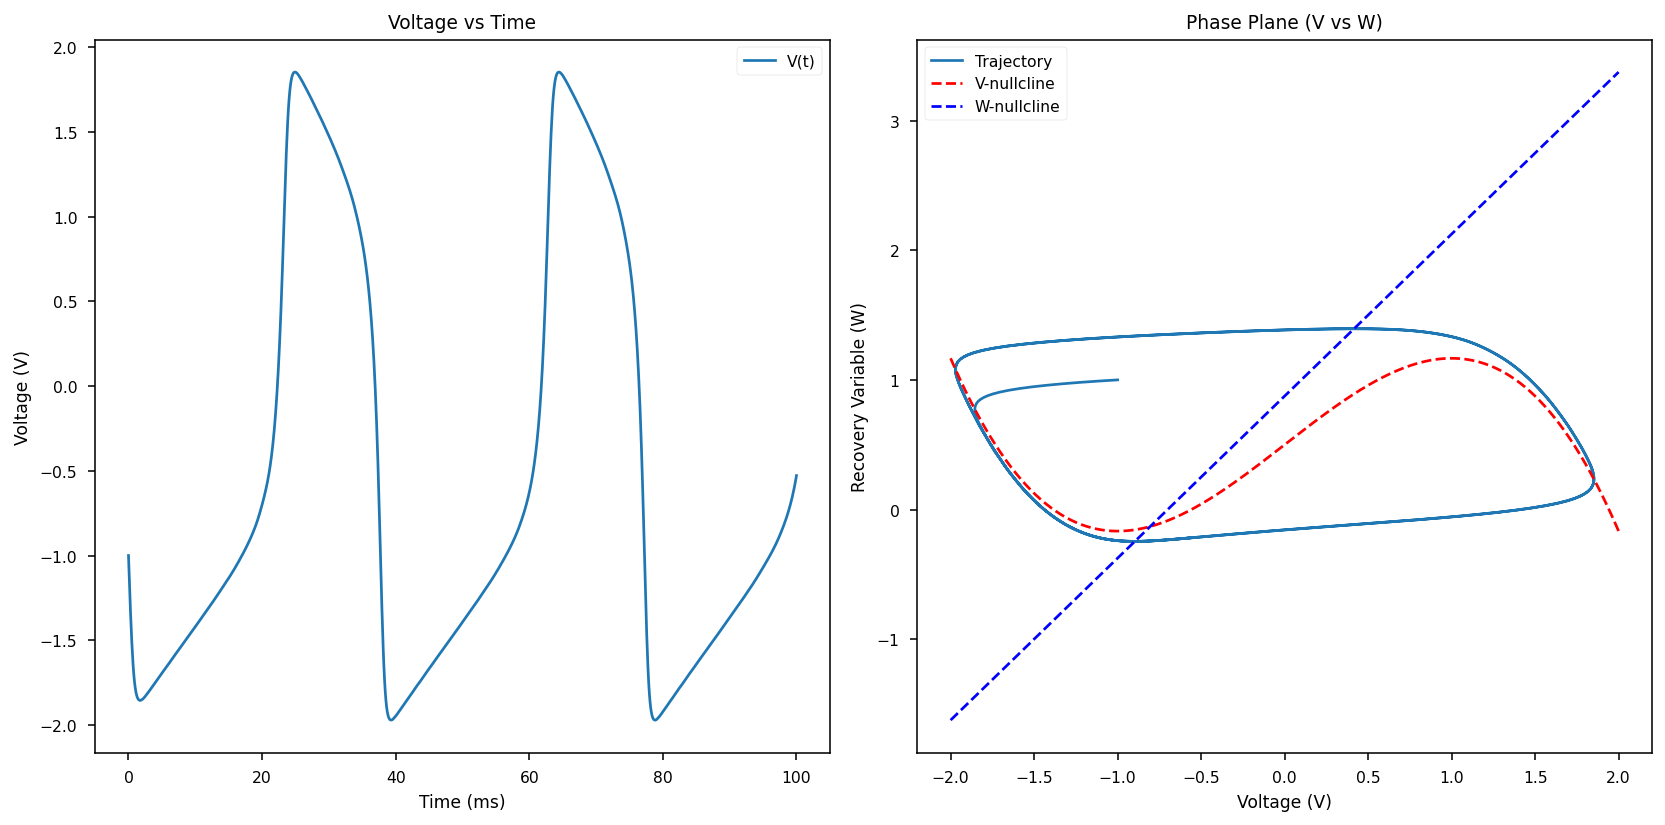

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the parameters
a = 0.7
b = 0.8
tau = 12.5
I_ext = 0.5

# Define the FitzHugh-Nagumo ODEs
def fhn_ode(t, y):
    V, W = y
    dVdt = V - V**3 / 3 - W + I_ext
    dWdt = (V + a - b * W) / tau
    return [dVdt, dWdt]

# Initial conditions
V0 = -1.0
W0 = 1.0
y0 = [V0, W0]

# Time span
t_span = (0, 100)
t_eval = np.linspace(0, 100, 1000)

# Solve the ODEs
sol = solve_ivp(fhn_ode, t_span, y0, t_eval=t_eval)

# Extract the solution
V = sol.y[0]
W = sol.y[1]
t = sol.t

# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot Voltage vs Time
ax1.plot(t, V, label='V(t)')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('Voltage vs Time')
ax1.legend()

# Plot the Phase Plane (V vs W)
ax2.plot(V, W, label='Trajectory')
ax2.set_xlabel('Voltage (V)')
ax2.set_ylabel('Recovery Variable (W)')
ax2.set_title('Phase Plane (V vs W)')

# Plot Nullclines
V_nullcline = np.linspace(-2, 2, 400)
W_nullcline = V_nullcline - V_nullcline**3 / 3 + I_ext
ax2.plot(V_nullcline, W_nullcline, 'r--', label='V-nullcline')

W_nullcline = (V_nullcline + a) / b
ax2.plot(V_nullcline, W_nullcline, 'b--', label='W-nullcline')

ax2.legend()

plt.tight_layout()
plt.show()

#### Explanation:
1. **ODE Definition:**
   - The function `fhn_ode` defines the FitzHugh-Nagumo ODEs.
   - The parameters \( a \), \( b \), and \( \tau \) are set to the given values.
   - The external current \( I_{\text{ext}} \) is set to 0.5.

2. **Initial Conditions:**
   - The initial conditions for \( V \) and \( W \) are set to \(-1.0\) and \(1.0\), respectively.

3. **Time Span and Evaluation:**
   - The time span is set from 0 to 100 ms.
   - The `t_eval` array is used to specify the time points at which the solution is evaluated.

4. **Solving the ODEs:**
   - The `solve_ivp` function from `scipy.integrate` is used to solve the ODEs.

5. **Plotting:**
   - The first subplot shows the voltage \( V \) as a function of time.
   - The second subplot shows the phase plane with the trajectory of \( V \) vs \( W \).
   - The nullclines are plotted as dashed lines:
     - The \( V \)-nullcline is where \( \frac{dV}{dt} = 0 \).
     - The \( W \)-nullcline is where \( \frac{dW}{dt} = 0 \).

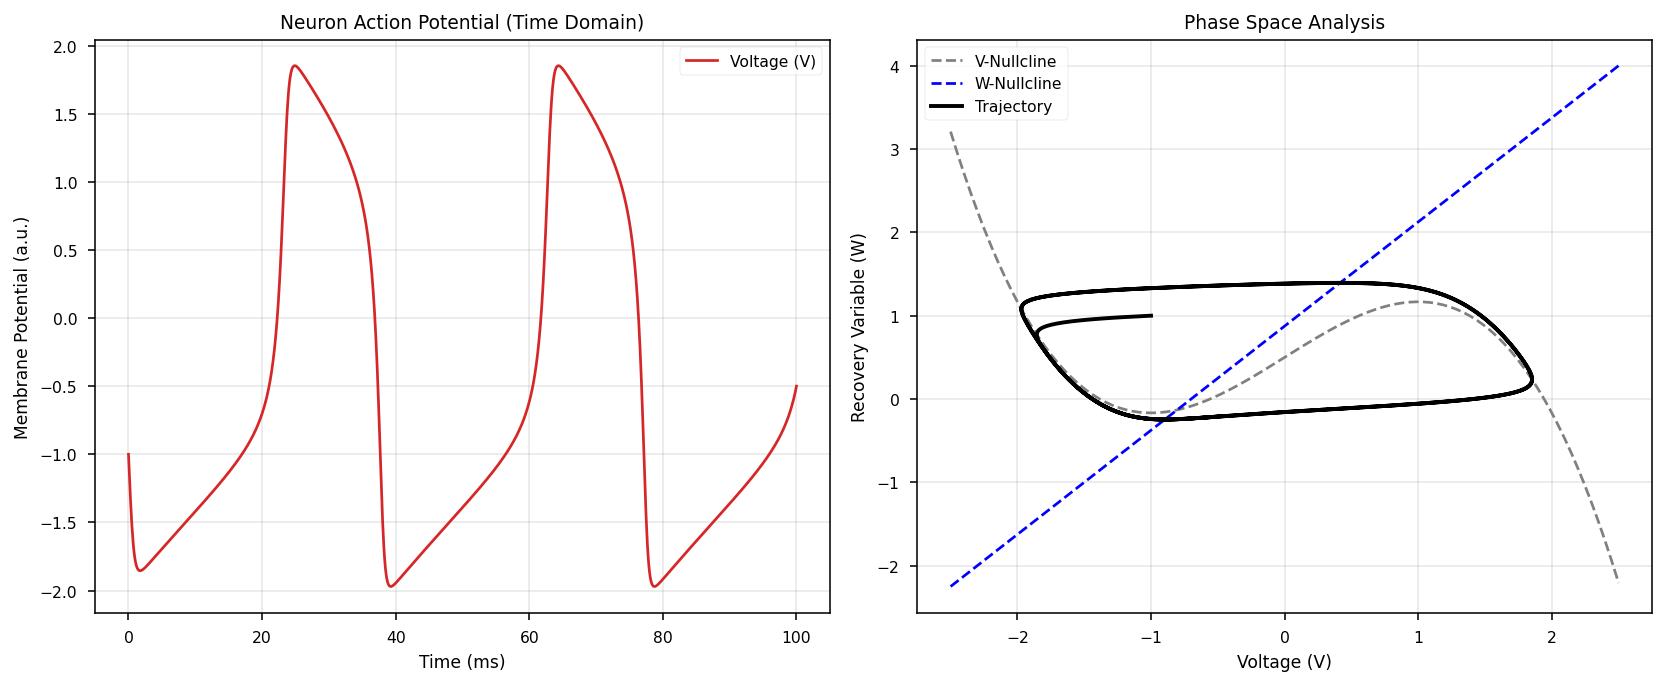

In [7]:
# ---------------------------------------------------------
# COPY/PASTE THE GENERATED CODE HERE TO RUN IT
# (Below is the Reference Implementation for the Notebook)
# ---------------------------------------------------------

def fhn_neuron(y, t, I_ext, a=0.7, b=0.8, tau=12.5):
    V, W = y
    # dV/dt = V - V^3/3 - W + I
    dVdt = V - (V**3)/3 - W + I_ext
    # dW/dt = (V + a - b*W) / tau
    dWdt = (V + a - b * W) / tau
    return [dVdt, dWdt]

# Parameters
t = np.linspace(0, 100, 1000)
y0 = [-1.0, 1.0] # Initial state (Resting)
I_ext = 0.5

# Integrate
sol = odeint(fhn_neuron, y0, t, args=(I_ext,))
V = sol[:, 0]
W = sol[:, 1]

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Time Series
ax[0].plot(t, V, label='Voltage (V)', color='#d62728')
ax[0].set_title("Neuron Action Potential (Time Domain)")
ax[0].set_xlabel("Time (ms)")
ax[0].set_ylabel("Membrane Potential (a.u.)")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Phase Plane & Nullclines
v_grid = np.linspace(-2.5, 2.5, 100)
# V-nullcline: dV/dt = 0 -> W = V - V^3/3 + I
w_null_v = v_grid - (v_grid**3)/3 + I_ext
# W-nullcline: dW/dt = 0 -> W = (V + a)/b
w_null_w = (v_grid + 0.7) / 0.8

ax[1].plot(v_grid, w_null_v, '--', label='V-Nullcline', color='grey')
ax[1].plot(v_grid, w_null_w, '--', label='W-Nullcline', color='blue')
ax[1].plot(V, W, '-', label='Trajectory', color='black', linewidth=2)
ax[1].set_title("Phase Space Analysis")
ax[1].set_xlabel("Voltage (V)")
ax[1].set_ylabel("Recovery Variable (W)")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

### Complementary Example: The Full Hodgkin-Huxley Model

The FitzHugh-Nagumo model gave us a clean, two-dimensional picture of excitability. But what did we lose in that simplification? To answer this, we now implement the **full Hodgkin-Huxley (HH) model** — the biophysically detailed description of the action potential that earned Alan Hodgkin and Andrew Huxley the 1952 Nobel Prize in Physiology or Medicine.

#### The biology: Three populations of ion channels

The HH model describes the membrane of the **squid giant axon** (diameter $\sim 0.5\;\text{mm}$, chosen for its size, which made electrophysiology feasible in 1952). Three distinct populations of ion channels cooperate to produce the action potential:

| Channel type | Ion | Role in the action potential | Gating variable(s) |
|---|---|---|---|
| **Voltage-gated Na$^+$** | $\text{Na}^+$ inward | Rapid **depolarization** — the upstroke of the spike | $m$ (activation, fast), $h$ (inactivation, slow) |
| **Delayed-rectifier K$^+$** | $\text{K}^+$ outward | **Repolarization** — brings $V$ back down | $n$ (activation, slow) |
| **Leak** | Mixed | Maintains the **resting potential** ($\approx -65\;\text{mV}$) | None (always open) |

Each channel type contributes a **current** to the total membrane current. The key insight of Hodgkin and Huxley was that the probability of a channel being open depends on voltage through **gating variables** ($m$, $h$, $n$), each of which obeys a first-order ODE with voltage-dependent rate constants.

#### The mathematics: A four-dimensional ODE system

The HH model describes the state of the membrane by four variables: the membrane potential $V$ and three gating variables $m$, $h$, $n \in [0, 1]$.

**Membrane potential** (current balance):

$$
C_m \frac{dV}{dt} = I_{\text{ext}} - \bar{g}_{\text{Na}}\, m^3 h\,(V - E_{\text{Na}}) - \bar{g}_{\text{K}}\, n^4\,(V - E_{\text{K}}) - \bar{g}_L\,(V - E_L)
$$

**Gating variables** (channel kinetics):

$$
\frac{dm}{dt} = \alpha_m(V)\,(1-m) - \beta_m(V)\,m
$$

$$
\frac{dh}{dt} = \alpha_h(V)\,(1-h) - \beta_h(V)\,h
$$

$$
\frac{dn}{dt} = \alpha_n(V)\,(1-n) - \beta_n(V)\,n
$$

| Parameter | Meaning | Value |
|---|---|---|
| $C_m$ | Membrane capacitance | $1.0\;\mu\text{F/cm}^2$ |
| $\bar{g}_{\text{Na}}$ | Max Na$^+$ conductance | $120\;\text{mS/cm}^2$ |
| $\bar{g}_{\text{K}}$ | Max K$^+$ conductance | $36\;\text{mS/cm}^2$ |
| $\bar{g}_L$ | Leak conductance | $0.3\;\text{mS/cm}^2$ |
| $E_{\text{Na}}$ | Na$^+$ reversal potential | $+50\;\text{mV}$ |
| $E_{\text{K}}$ | K$^+$ reversal potential | $-77\;\text{mV}$ |
| $E_L$ | Leak reversal potential | $-54.387\;\text{mV}$ |

The rate functions $\alpha_x(V)$ and $\beta_x(V)$ are empirical fits to voltage-clamp data from squid axon experiments.

**For the medical student:** Each term in the membrane equation is a **macroscopic ionic current** that you can relate directly to the physiology: $\bar{g}_{\text{Na}}\,m^3 h\,(V - E_{\text{Na}})$ is the Na$^+$ current through voltage-gated channels. The factor $m^3$ means three activation "gates" must open (fast process), while $h$ represents inactivation (slow process that shuts the channel after a delay). The product $m^3 h$ rises and then falls — this is exactly the transient Na$^+$ current that produces the spike upstroke. Similarly, $n^4$ represents the delayed opening of K$^+$ channels that repolarizes the membrane.

**For the applied mathematician:** The HH system lives in $\mathbb{R}^4$, so phase-plane analysis is not directly applicable. The time-scale separation between the fast variables ($V$, $m$) and slow variables ($h$, $n$) is what motivates the FHN reduction: $V$ and $m$ are lumped into a single fast variable, while $h$ and $n$ (which are approximately linearly related along trajectories) become the single slow recovery variable $W$. The cubic nullcline in FHN arises from the $m^3$-dependent Na$^+$ current at quasi-steady state ($m \approx m_\infty(V)$).

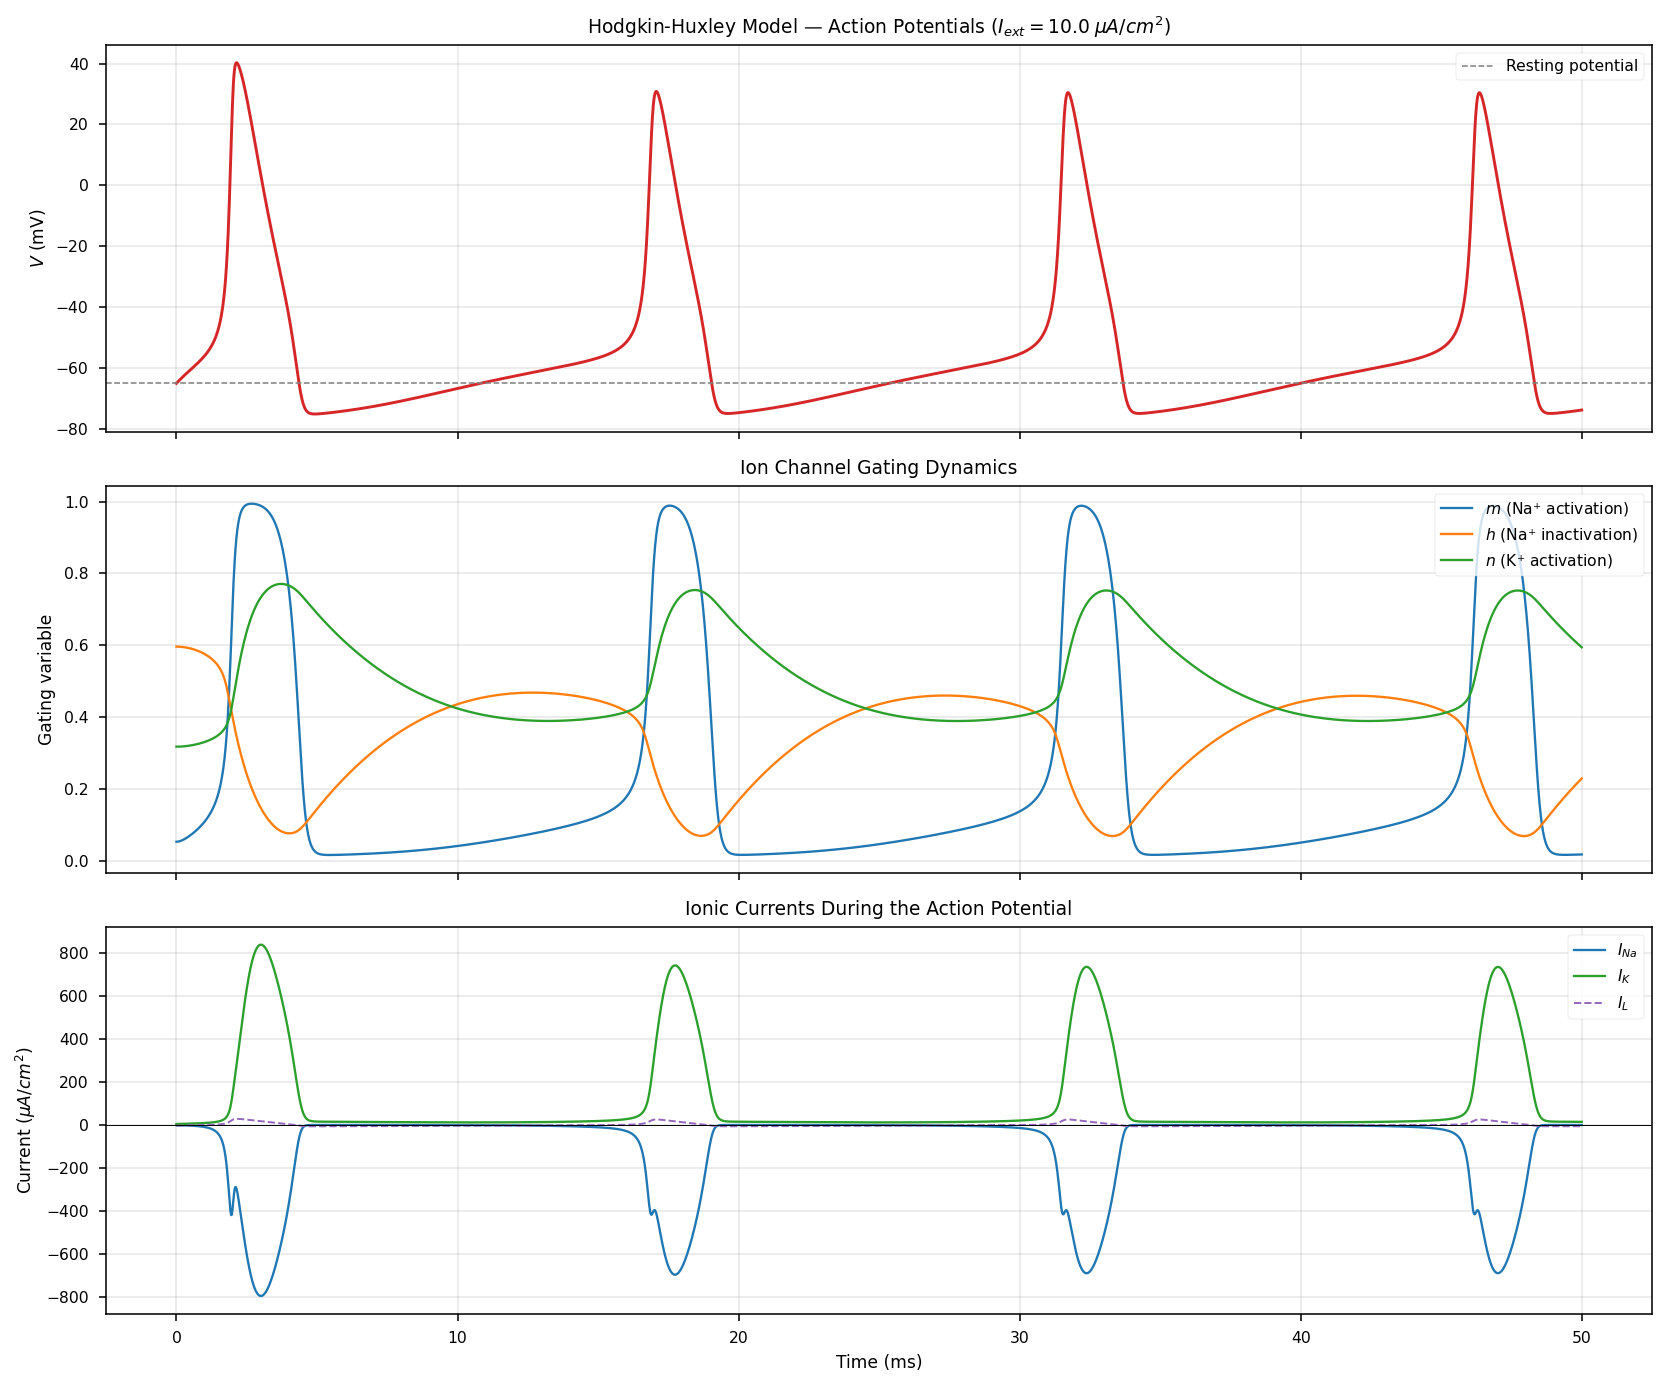

In [8]:
# =============================================================
# Hodgkin-Huxley Model — Full Biophysical Implementation
# (Standard Python: NumPy + SciPy + Matplotlib — runs everywhere)
# =============================================================

from scipy.integrate import solve_ivp

# --- HH Parameters (squid giant axon, Hodgkin & Huxley 1952) ---
C_m  = 1.0      # Membrane capacitance (μF/cm²)
g_Na = 120.0    # Max Na⁺ conductance (mS/cm²)
g_K  = 36.0     # Max K⁺  conductance (mS/cm²)
g_L  = 0.3      # Leak conductance    (mS/cm²)
E_Na = 50.0     # Na⁺ reversal potential (mV)
E_K  = -77.0    # K⁺  reversal potential (mV)
E_L  = -54.387  # Leak reversal potential (mV)

# --- Rate functions α(V) and β(V) for each gating variable ---
def alpha_m(V): return 0.1 * (V + 40.0) / (1.0 - np.exp(-(V + 40.0) / 10.0))
def beta_m(V):  return 4.0 * np.exp(-(V + 65.0) / 18.0)
def alpha_h(V): return 0.07 * np.exp(-(V + 65.0) / 20.0)
def beta_h(V):  return 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))
def alpha_n(V): return 0.01 * (V + 55.0) / (1.0 - np.exp(-(V + 55.0) / 10.0))
def beta_n(V):  return 0.125 * np.exp(-(V + 65.0) / 80.0)

# Steady-state and time constant (useful for initial conditions)
def x_inf(alpha, beta): return alpha / (alpha + beta)

# --- The ODE system: dY/dt = f(t, Y) ---
def hodgkin_huxley(t, Y, I_ext):
    V, m, h, n = Y
    
    # Ionic currents
    I_Na = g_Na * m**3 * h * (V - E_Na)
    I_K  = g_K  * n**4     * (V - E_K)
    I_L  = g_L              * (V - E_L)
    
    # Derivatives
    dVdt = (I_ext - I_Na - I_K - I_L) / C_m
    dmdt = alpha_m(V) * (1 - m) - beta_m(V) * m
    dhdt = alpha_h(V) * (1 - h) - beta_h(V) * h
    dndt = alpha_n(V) * (1 - n) - beta_n(V) * n
    
    return [dVdt, dmdt, dhdt, dndt]

# --- Simulation ---
I_ext = 10.0  # External current (μA/cm²) — enough to elicit repetitive firing
t_span = (0, 50)  # 50 ms
t_eval = np.linspace(*t_span, 5000)

# Initial conditions at resting potential
V0 = -65.0
m0 = x_inf(alpha_m(V0), beta_m(V0))
h0 = x_inf(alpha_h(V0), beta_h(V0))
n0 = x_inf(alpha_n(V0), beta_n(V0))

sol = solve_ivp(hodgkin_huxley, t_span, [V0, m0, h0, n0],
                args=(I_ext,), t_eval=t_eval, method='RK45', rtol=1e-8)

V_hh = sol.y[0]
m_hh = sol.y[1]
h_hh = sol.y[2]
n_hh = sol.y[3]
t_hh = sol.t

# --- Compute individual ionic currents for plotting ---
I_Na_t = g_Na * m_hh**3 * h_hh * (V_hh - E_Na)
I_K_t  = g_K  * n_hh**4          * (V_hh - E_K)
I_L_t  = g_L                      * (V_hh - E_L)

# --- Figure: 3-panel plot ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: Membrane Potential
axes[0].plot(t_hh, V_hh, color='#d62728', lw=1.5)
axes[0].set_ylabel('$V$ (mV)')
axes[0].set_title(f'Hodgkin-Huxley Model — Action Potentials ($I_{{ext}} = {I_ext}\\;\\mu A/cm^2$)')
axes[0].axhline(-65, color='gray', ls='--', lw=0.8, label='Resting potential')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel 2: Gating Variables
axes[1].plot(t_hh, m_hh, label='$m$ (Na⁺ activation)', color='#1f77b4', lw=1.2)
axes[1].plot(t_hh, h_hh, label='$h$ (Na⁺ inactivation)', color='#ff7f0e', lw=1.2)
axes[1].plot(t_hh, n_hh, label='$n$ (K⁺ activation)', color='#2ca02c', lw=1.2)
axes[1].set_ylabel('Gating variable')
axes[1].set_title('Ion Channel Gating Dynamics')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Panel 3: Ionic Currents
axes[2].plot(t_hh, I_Na_t, label='$I_{Na}$', color='#1f77b4', lw=1.2)
axes[2].plot(t_hh, I_K_t,  label='$I_K$',  color='#2ca02c', lw=1.2)
axes[2].plot(t_hh, I_L_t,  label='$I_L$',  color='#9467bd', lw=1.0, ls='--')
axes[2].axhline(0, color='black', lw=0.5)
axes[2].set_ylabel('Current ($\\mu A/cm^2$)')
axes[2].set_xlabel('Time (ms)')
axes[2].set_title('Ionic Currents During the Action Potential')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Reading the Hodgkin-Huxley Plots

The three-panel figure above reveals the **molecular choreography** of the action potential:

**Panel 1 — Membrane potential $V(t)$:**
Each spike follows the characteristic shape: a rapid upstroke (depolarization), a sharp peak near $+40\;\text{mV}$, a fast repolarization, and a brief undershoot (hyperpolarization) below resting potential before recovery. Under sustained current injection ($I_{\text{ext}} = 10\;\mu\text{A/cm}^2$), the neuron fires repetitively — this is the regime above the Hopf bifurcation threshold.

**Panel 2 — Gating variables $m(t)$, $h(t)$, $n(t)$:**
This is where the biophysical detail lives:
- $m$ (Na$^+$ activation, blue) rises **extremely fast** at spike onset — this is the positive-feedback loop that drives depolarization.
- $h$ (Na$^+$ inactivation, orange) falls on a **slower time scale** — it shuts off the Na$^+$ current even while $V$ is still high, terminating the upstroke.
- $n$ (K$^+$ activation, green) rises **slowly** — it opens the K$^+$ channels that drive repolarization and the undershoot.

The interplay of these three variables produces the spike. Notice that $m$ and $V$ move together (both fast), while $h$ and $n$ move together (both slow) — this is exactly the time-scale separation that justifies the FHN reduction.

**Panel 3 — Ionic currents:**
- The large inward (negative) $I_{\text{Na}}$ spike is the Na$^+$ current driving depolarization.
- The outward (positive) $I_K$ peak follows with a delay — this is the "delayed rectifier" current that repolarizes the membrane.
- The leak current $I_L$ is small and approximately constant — it helps set the resting potential.

#### From HH to FHN — What the Simplification Preserves and What It Loses

| Feature | Hodgkin-Huxley (4D) | FitzHugh-Nagumo (2D) |
|---|---|---|
| **Variables** | $V$, $m$, $h$, $n$ | $V$ (fast), $W$ (slow) |
| **Ion channels** | Na$^+$ ($m^3 h$), K$^+$ ($n^4$), Leak | Abstracted into cubic nonlinearity |
| **Time-scale separation** | Implicit ($m$ fast, $h$/$n$ slow) | Explicit ($\epsilon \ll 1$) |
| **Phase-plane analysis** | Not possible (4D) | Full nullcline / bifurcation analysis (2D) |
| **Quantitative predictions** | Yes (matches squid axon data) | No (qualitative only) |
| **Pharmacological modeling** | Yes (block specific channels) | No (no individual channel identity) |
| **Excitability & oscillations** | ✓ | ✓ |
| **Threshold behavior** | ✓ | ✓ |
| **Refractory period** | ✓ | ✓ |

**The take-away:** The FHN model preserves the **qualitative dynamical features** (excitability, threshold, refractoriness, oscillation) while sacrificing **biophysical interpretability** (which channel does what). For clinical applications where you need to model drug effects on specific ion channels (e.g., Na$^+$ channel blockers in epilepsy, K$^+$ channel openers in cardiac arrhythmia), the HH-type model is essential. For understanding the *geometry* of excitability and bifurcation structure, the FHN model is the right tool.

## Example 2: Stochastic Processes (Membrane Noise)

Biological systems are noisy. The standard `odeint` solver cannot handle noise (randomness) because the derivative $dW_t/dt$ is undefined. We must use **Stochastic Differential Equations (SDEs)**.

**The Prompt:**
We ask the model to simulate an **Ornstein-Uhlenbeck (OU)** process, often used to model background synaptic noise or membrane voltage fluctuations. Note that the System Prompt enforces the **Euler-Maruyama** method.

In [9]:
query_sde = """
Simulate the membrane potential noise of a neuron using an Ornstein-Uhlenbeck process.
Equation: dV = theta * (mu - V) * dt + sigma * dW
Parameters: theta=0.1 (decay), mu=-65 (resting mV), sigma=2.0 (noise).
Time: 0 to 1000ms.
Use the Euler-Maruyama method explicitly.
"""

if HAS_MLX:
    response_sde = ask_professor(query_sde)
    print(response_sde)
else:
    print("⏭️  LLM not available — see pre-generated response in the markdown cell below.")

🧠 Professor is thinking about: '
Simulate the membrane potential noise of a neuron using an Ornstein-Uhlenbeck process.
Equation: dV = theta * (mu - V) * dt + sigma * dW
Parameters: theta=0.1 (decay), mu=-65 (resting mV), sigma=2.0 (noise).
Time: 0 to 1000ms.
Use the Euler-Maruyama method explicitly.
'...
✅ Generated in 85.97s
Certainly! The Ornstein-Uhlenbeck (OU) process is a stochastic process that describes the velocity of a particle undergoing Brownian motion with friction. In the context of neuronal membrane potential, it can be used to model the fluctuations around a resting potential.

### Governing Equation
The OU process for the membrane potential \( V(t) \) is given by the stochastic differential equation (SDE):

\[
dV = \theta (\mu - V) \, dt + \sigma \, dW
\]

where:
- \( V \) is the membrane potential.
- \( \theta \) is the decay rate (0.1).
- \( \mu \) is the resting potential (-65 mV).
- \( \sigma \) is the noise amplitude (2.0).
- \( dW \) is the Wiener process increme

🧠 Professor is thinking about: '
Simulate the membrane potential noise of a neuron using an Ornstein-Uhlenbeck process.
Equation: dV = theta * (mu - V) * dt + sigma * dW
Parameters: theta=0.1 (decay), mu=-65 (resting mV), sigma=2.0 (noise).
Time: 0 to 1000ms.
Use the Euler-Maruyama method explicitly.
'...
✅ Generated in 70.78s
Certainly! To simulate the membrane potential noise of a neuron using an Ornstein-Uhlenbeck process, we will use the Euler-Maruyama method. The governing equation for the Ornstein-Uhlenbeck process is:

\[
dV = \theta (\mu - V) dt + \sigma dW
\]

where:
- \( V \) is the membrane potential.
- \( \theta \) is the decay rate.
- \( \mu \) is the resting potential.
- \( \sigma \) is the noise intensity.
- \( dW \) is the Wiener process increment.

Given parameters:
- \( \theta = 0.1 \) (decay rate)
- \( \mu = -65 \) mV (resting potential)
- \( \sigma = 2.0 \) (noise intensity)
- Time interval: \( t \in [0, 1000] \) ms

We will use the Euler-Maruyama method to discretize the stochastic differential equation (SDE):

\[
V_{t+\Delta t} = V_t + \theta (\mu - V_t) \Delta t + \sigma \sqrt{\Delta t} \mathcal{N}(0, 1)
\]

where \( \mathcal{N}(0, 1) \) is a standard normal random variable.

Here is the Python code to simulate this process:

```python
import numpy as np
import matplotlib.pyplot as plt

# Parameters
theta = 0.1  # decay rate
mu = -65.0   # resting potential (mV)
sigma = 2.0  # noise intensity
T = 1000.0   # total time (ms)
dt = 1.0     # time step (ms)
num_steps = int(T / dt)  # number of time steps

# Initialize membrane potential
V = np.zeros(num_steps)
V[0] = mu  # initial condition

# Time array
time = np.arange(0, T, dt)

# Euler-Maruyama method
for t in range(1, num_steps):
    dW = np.random.normal(0, np.sqrt(dt))  # Wiener process increment
    V[t] = V[t-1] + theta * (mu - V[t-1]) * dt + sigma * dW

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(time, V, label='Membrane Potential (mV)')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.title('Ornstein-Uhlenbeck Process for Neuron Membrane Potential')
plt.legend()
plt.grid(True)
plt.show()
```

### Explanation:
1. **Parameters**: We define the parameters \( \theta \), \( \mu \), \( \sigma \), total time \( T \), and time step \( dt \).
2. **Initialization**: We initialize the membrane potential array \( V \) with the initial condition \( V_0 = \mu \).
3. **Time Array**: We create a time array from 0 to \( T \) with a step size of \( dt \).
4. **Euler-Maruyama Method**: We iterate through each time step, updating the membrane potential using the Euler-Maruyama method.
5. **Plotting**: We plot the membrane potential over time to visualize the Ornstein-Uhlenbeck process.

This code will generate a plot showing the membrane potential of the neuron over the specified time interval, incorporating the specified noise and decay parameters.

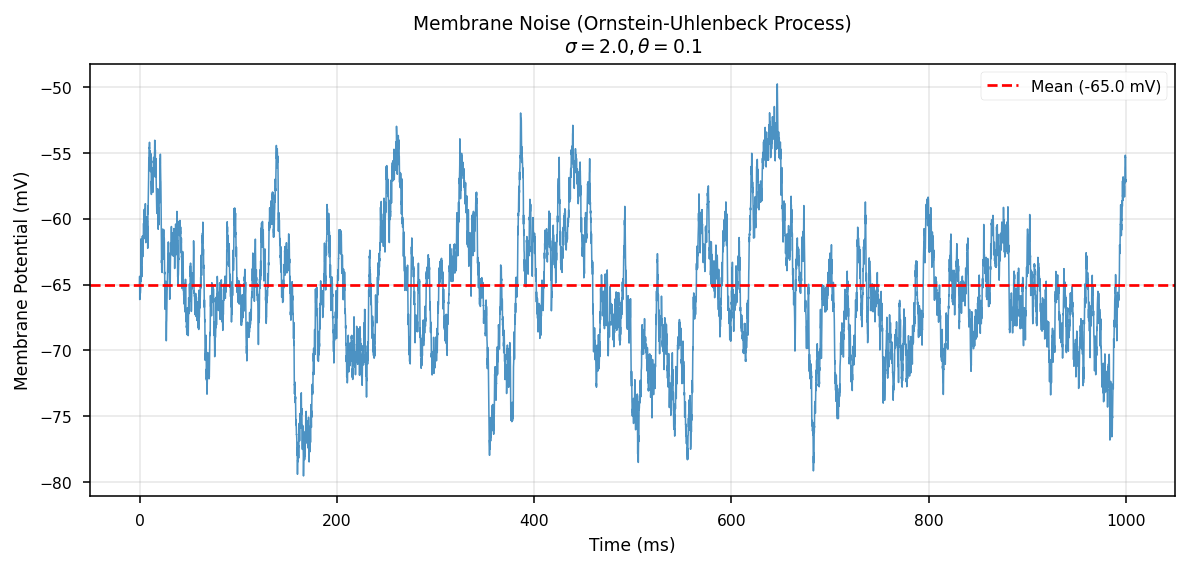

In [10]:
# ---------------------------------------------------------
# Reference Implementation (Euler-Maruyama)
# ---------------------------------------------------------

# Parameters
theta = 0.1   # Speed of reversion to mean
mu = -65.0    # Resting potential (mV)
sigma = 2.0   # Volatility (Noise intensity)
T = 1000      # Total time (ms)
dt = 0.1      # Time step
N = int(T / dt)

# Arrays
t = np.linspace(0, T, N)
V = np.zeros(N)
V[0] = -65.0 # Initial condition

# Euler-Maruyama Loop
# dW is sampled from Normal(0, sqrt(dt))
# We generate all random numbers at once for vectorization speed (M4 Max optimization)
dW = np.random.normal(0, np.sqrt(dt), N)

for i in range(1, N):
    drift = theta * (mu - V[i-1]) * dt
    diffusion = sigma * dW[i]
    V[i] = V[i-1] + drift + diffusion

# Visualization
plt.figure(figsize=(10, 4))
plt.plot(t, V, color='#1f77b4', lw=0.8, alpha=0.8)
plt.axhline(mu, color='red', linestyle='--', label=f'Mean ({mu} mV)')
plt.title(f"Membrane Noise (Ornstein-Uhlenbeck Process)\n$\\sigma={sigma}, \\theta={theta}$")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Example 3: Medical Physics (MRI T1 Relaxation)



[Image of MRI Scanner Physics]


Finally, we look at **Computational Medicine**. In MRI, protons precess in a magnetic field. The **Bloch Equations** describe how the magnetization vector $\vec{M} = (M_x, M_y, M_z)$ relaxes back to equilibrium.

**The Prompt:**
We need to verify if the model can handle the 3D vector math and loop-free coding required for efficient image simulation.

In [11]:
%%time
# We ask the LLM to describe the Bloch Equations and generate T1 relaxation code
query_mri = """
I need to model MRI T1 relaxation using the Bloch Equations.
1. Describe conceptually how the magnetization vector M = (Mx, My, Mz) relaxes back
   to thermal equilibrium after an RF excitation pulse in a static magnetic field B0.
2. State the governing Bloch Equations mathematically (using latex);
   do not use \\[ and \\] but $$, not \\( X \\) but $X$ where X is a symbol or string.
   Explain the role of the relaxation times T1 (longitudinal/spin-lattice) and
   T2 (transverse/spin-spin).
3. For the special case of longitudinal recovery (Mz component only), implement:
   Mz(t) = M0 * (1 - exp(-t / T1))
   Parameters:
   - M0 = 1.0 (normalized equilibrium magnetization)
   - T1 values for brain tissues: CSF = 4000ms, Gray Matter = 1300ms, White Matter = 800ms
   - Time vector: 0 to 5000ms, 500 points.
   Use numpy vectorization (no loops over time).
4. Plot all three T1 recovery curves on a single figure with:
   - Labeled curves showing tissue name and T1 value.
   - An annotation highlighting the 'Contrast Window' near t=1000ms
     where the curves diverge, explaining why TR choice determines image contrast.
"""

if HAS_MLX:
    response_mri = ask_professor(query_mri)
    print(response_mri)
else:
    print("⏭️  LLM not available — see pre-generated response in the markdown cell below.")

🧠 Professor is thinking about: '
I need to model MRI T1 relaxation using the Bloch Equations.
1. Describe conceptually how the magnetization vector M = (Mx, My, Mz) relaxes back
   to thermal equilibrium after an RF excitation pulse in a static magnetic field B0.
2. State the governing Bloch Equations mathematically (using latex);
   do not use \[ and \] but $$, not \( X \) but $X$ where X is a symbol or string.
   Explain the role of the relaxation times T1 (longitudinal/spin-lattice) and
   T2 (transverse/spin-spin).
3. For the special case of longitudinal recovery (Mz component only), implement:
   Mz(t) = M0 * (1 - exp(-t / T1))
   Parameters:
   - M0 = 1.0 (normalized equilibrium magnetization)
   - T1 values for brain tissues: CSF = 4000ms, Gray Matter = 1300ms, White Matter = 800ms
   - Time vector: 0 to 5000ms, 500 points.
   Use numpy vectorization (no loops over time).
4. Plot all three T1 recovery curves on a single figure with:
   - Labeled curves showing tissue name and T1

🧠 Professor is thinking about: '
I need to model MRI T1 relaxation using the Bloch Equations.
1. Describe conceptually how the magnetization vector M = (Mx, My, Mz) relaxes back
   to thermal equilibrium after an RF excitation pulse in a static magnetic field B0.
2. State the governing Bloch Equations mathematically (using latex);
   do not use \[ and \] but $$, not \( X \) but $X$ where X is a symbol or string.
   Explain the role of the relaxation times T1 (longitudinal/spin-lattice) and
   T2 (transverse/spin-spin).
3. For the special case of longitudinal recovery (Mz component only), implement:
   Mz(t) = M0 * (1 - exp(-t / T1))
   Parameters:
   - M0 = 1.0 (normalized equilibrium magnetization)
   - T1 values for brain tissues: CSF = 4000ms, Gray Matter = 1300ms, White Matter = 800ms
   - Time vector: 0 to 5000ms, 500 points.
   Use numpy vectorization (no loops over time).
4. Plot all three T1 recovery curves on a single figure with:
   - Labeled curves showing tissue name and T1 value.
   - An annotation highlighting the 'Contrast Window' near t=1000ms
     where the curves diverge, explaining why TR choice determines image contrast.
'...
✅ Generated in 107.97s
### 1. Conceptual Description of MRI T1 Relaxation

After an RF excitation pulse, the magnetization vector \( \mathbf{M} = (M_x, M_y, M_z) \) is perturbed from its equilibrium state. The RF pulse typically tips the magnetization vector into the transverse plane (x-y plane), and the system then relaxes back to its equilibrium state in the presence of a static magnetic field \( B_0 \).

- **Longitudinal Relaxation (T1):** The recovery of the \( M_z \) component back to its equilibrium value \( M_0 \). This process is governed by the longitudinal relaxation time \( T_1 \).
- **Transverse Relaxation (T2):** The decay of the transverse components \( M_x \) and \( M_y \) due to dephasing of the magnetization vectors. This process is governed by the transverse relaxation time \( T_2 \).

### 2. Governing Bloch Equations

The Bloch equations describe the time evolution of the magnetization vector \( \mathbf{M} \) in the presence of a static magnetic field \( B_0 \) and an RF pulse. The equations are given by:

$$
\frac{dM_x}{dt} = \gamma (M_y B_z - M_z B_y) - \frac{M_x}{T_2}
$$
$$
\frac{dM_y}{dt} = \gamma (M_z B_x - M_x B_z) - \frac{M_y}{T_2}
$$
$$
\frac{dM_z}{dt} = \gamma (M_x B_y - M_y B_x) - \frac{M_z - M_0}{T_1}
$$

where:
- \( \gamma \) is the gyromagnetic ratio.
- \( B_x, B_y, B_z \) are the components of the magnetic field.
- \( M_0 \) is the equilibrium magnetization.
- \( T_1 \) is the longitudinal relaxation time.
- \( T_2 \) is the transverse relaxation time.

### 3. Longitudinal Recovery (Mz Component)

For the special case of longitudinal recovery, the \( M_z \) component can be described by the following equation:

$$
M_z(t) = M_0 \left(1 - \exp\left(-\frac{t}{T_1}\right)\right)
$$

Given parameters:
- \( M_0 = 1.0 \) (normalized equilibrium magnetization)
- \( T_1 \) values for brain tissues:
  - CSF: 4000 ms
  - Gray Matter: 1300 ms
  - White Matter: 800 ms
- Time vector: 0 to 5000 ms, 500 points.

### 4. Implementation and Plot

```python
import numpy as np
import matplotlib.pyplot as plt

# Parameters
M0 = 1.0
T1_values = {'CSF': 4000, 'Gray Matter': 1300, 'White Matter': 800}
time = np.linspace(0, 5000, 500)

# Compute Mz(t) for each tissue
Mz = {tissue: M0 * (1 - np.exp(-time / T1)) for tissue, T1 in T1_values.items()}

# Plotting
plt.figure(figsize=(10, 6))
for tissue, T1 in T1_values.items():
    plt.plot(time, Mz[tissue], label=f'{tissue} (T1 = {T1} ms)')

# Highlight the 'Contrast Window'
plt.axvspan(900, 1100, color='gray', alpha=0.3, label='Contrast Window (t=1000ms)')

# Annotations
plt.annotate('Contrast Window', xy=(1000, 0.5), xytext=(1000, 0.7),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='center', verticalalignment='bottom')

# Labels and legend
plt.xlabel('Time (ms)')
plt.ylabel('Mz(t)')
plt.title('Longitudinal Recovery (Mz) for Different Brain Tissues')
plt.legend()
plt.grid(True)
plt.show()
```

### Explanation of the 'Contrast Window'

The 'Contrast Window' near \( t = 1000 \) ms is a critical region where the recovery curves for different tissues begin to diverge. This divergence is due to the different \( T_1 \) values of the tissues. The choice of the repetition time \( TR \) in MRI sequences determines the contrast in the images. If \( TR \) is set within the 'Contrast Window', the differences in \( T_1 \) relaxation times will be emphasized, leading to better contrast between tissues with different \( T_1 \) values. For example, setting \( TR \) around 1000 ms will enhance the contrast between CSF and gray matter, making it easier to distinguish these tissues in the MRI images.
CPU times: user 15.3 s, sys: 8.87 s, total: 24.2 s
Wall time: 1min 47s

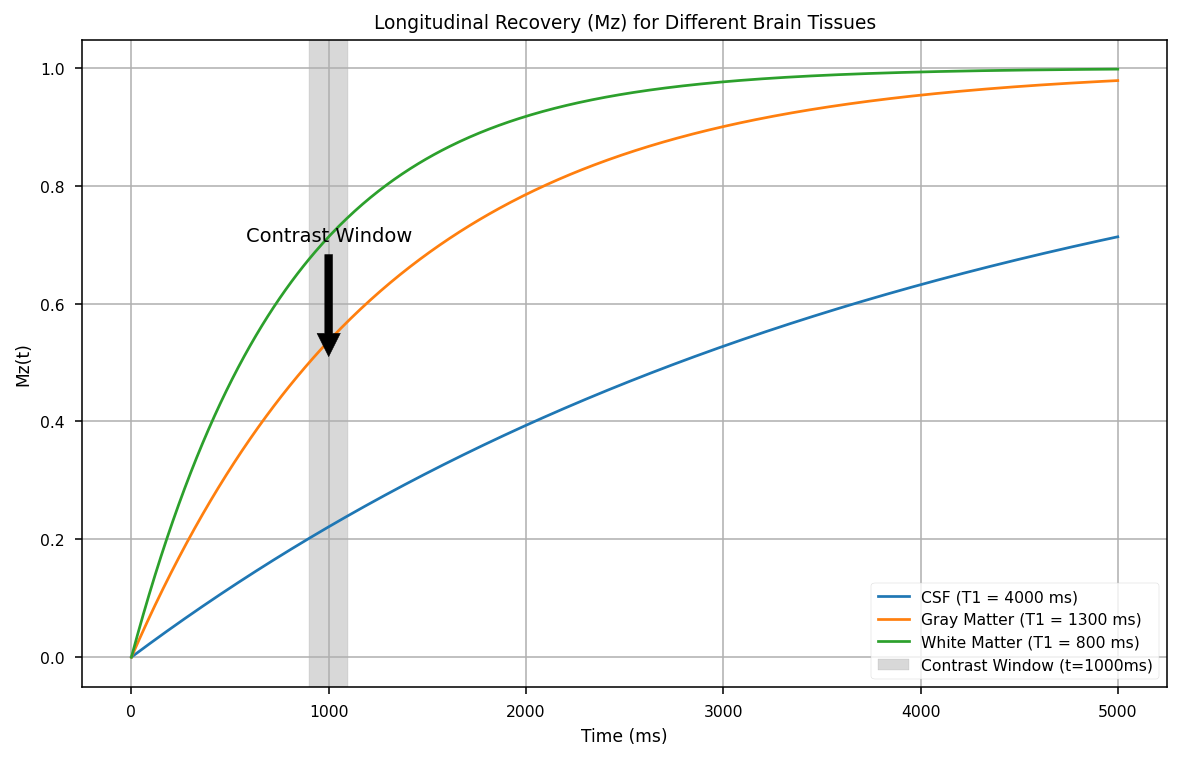

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
M0 = 1.0
T1_values = {'CSF': 4000, 'Gray Matter': 1300, 'White Matter': 800}
time = np.linspace(0, 5000, 500)

# Compute Mz(t) for each tissue
Mz = {tissue: M0 * (1 - np.exp(-time / T1)) for tissue, T1 in T1_values.items()}

# Plotting
plt.figure(figsize=(10, 6))
for tissue, T1 in T1_values.items():
    plt.plot(time, Mz[tissue], label=f'{tissue} (T1 = {T1} ms)')

# Highlight the 'Contrast Window'
plt.axvspan(900, 1100, color='gray', alpha=0.3, label='Contrast Window (t=1000ms)')

# Annotations
plt.annotate('Contrast Window', xy=(1000, 0.5), xytext=(1000, 0.7),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='center', verticalalignment='bottom')

# Labels and legend
plt.xlabel('Time (ms)')
plt.ylabel('Mz(t)')
plt.title('Longitudinal Recovery (Mz) for Different Brain Tissues')
plt.legend()
plt.grid(True)
plt.show()

#### Explanation of the 'Contrast Window'

The 'Contrast Window' near \( t = 1000 \) ms is a critical region where the recovery curves for different tissues begin to diverge. This divergence is due to the different \( T_1 \) values of the tissues. The choice of the repetition time \( TR \) in MRI sequences determines the contrast in the images. If \( TR \) is set within the 'Contrast Window', the differences in \( T_1 \) relaxation times will be emphasized, leading to better contrast between tissues with different \( T_1 \) values. For example, setting \( TR \) around 1000 ms will enhance the contrast between CSF and gray matter, making it easier to distinguish these tissues in the MRI images.

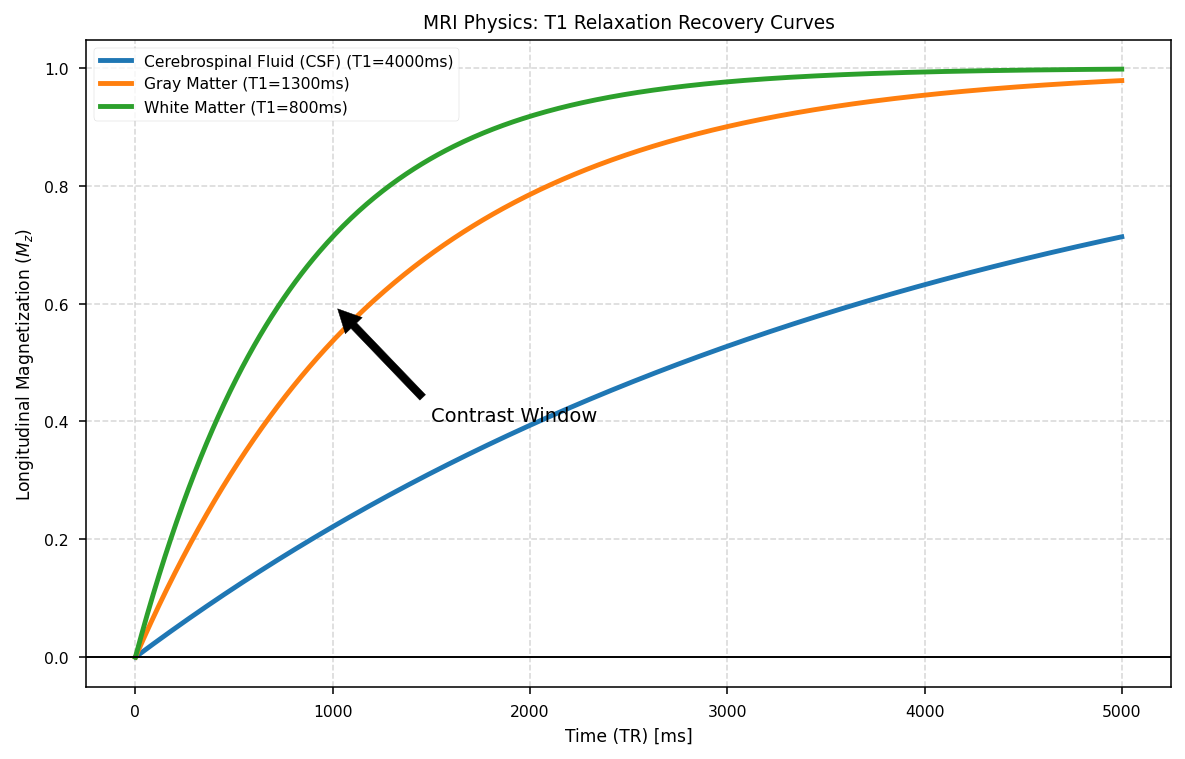

In [13]:
# ---------------------------------------------------------
# Reference Implementation
# ---------------------------------------------------------

# Time vector
t = np.linspace(0, 5000, 500) # 0 to 5 seconds
M0 = 1.0 # Normalized initial magnetization

# T1 values for brain tissues (in ms)
tissues = {
    "Cerebrospinal Fluid (CSF)": 4000,
    "Gray Matter": 1300,
    "White Matter": 800
}

plt.figure(figsize=(10, 6))

for name, T1 in tissues.items():
    # Vectorized calculation (No loops over time t)
    Mz = M0 * (1 - np.exp(-t / T1))
    plt.plot(t, Mz, label=f"{name} (T1={T1}ms)", lw=2.5)

plt.axhline(0, color='black', lw=1)
plt.title("MRI Physics: T1 Relaxation Recovery Curves")
plt.xlabel("Time (TR) [ms]")
plt.ylabel("Longitudinal Magnetization ($M_z$)")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Highlight: This intersection shows why image contrast depends on timing
plt.annotate('Contrast Window', xy=(1000, 0.6), xytext=(1500, 0.4),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()